In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path



In [75]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [76]:
TRAIN_PATH = "../data/raw/train_FD001.txt"
TEST_PATH = "../data/raw/test_FD001.txt"
RUL_PATH = "../data/raw/RUL_FD001.txt"

In [77]:

COLUMNS = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

In [78]:
train_df = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=COLUMNS
)

In [79]:
train_df.shape

(20631, 26)

In [80]:

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=COLUMNS
)
test_df.shape

(13096, 26)

In [81]:

rul_df = pd.read_csv(
    RUL_PATH,
    header=None,
    names=["RUL"]
)

rul_df.shape

(100, 1)

In [82]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [83]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  13096 non-null  int64  
 1   cycle      13096 non-null  int64  
 2   setting_1  13096 non-null  float64
 3   setting_2  13096 non-null  float64
 4   setting_3  13096 non-null  float64
 5   sensor_1   13096 non-null  float64
 6   sensor_2   13096 non-null  float64
 7   sensor_3   13096 non-null  float64
 8   sensor_4   13096 non-null  float64
 9   sensor_5   13096 non-null  float64
 10  sensor_6   13096 non-null  float64
 11  sensor_7   13096 non-null  float64
 12  sensor_8   13096 non-null  float64
 13  sensor_9   13096 non-null  float64
 14  sensor_10  13096 non-null  float64
 15  sensor_11  13096 non-null  float64
 16  sensor_12  13096 non-null  float64
 17  sensor_13  13096 non-null  float64
 18  sensor_14  13096 non-null  float64
 19  sensor_15  13096 non-null  float64
 20  sensor

In [84]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [85]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,13096.0,51.543907,2.828942e+01,1.0000,28.0000,52.0000,76.0000,100.0000
cycle,13096.0,76.836515,5.305775e+01,1.0000,33.0000,69.0000,113.0000,303.0000
setting_1,13096.0,-0.000011,2.202685e-03,-0.0082,-0.0015,-0.0000,0.0015,0.0078
setting_2,13096.0,0.000004,2.940306e-04,-0.0006,-0.0002,-0.0000,0.0003,0.0007
setting_3,13096.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,13096.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,13096.0,642.475088,4.008993e-01,641.1300,642.1975,642.4600,642.7400,644.3000
sensor_3,13096.0,1588.099204,5.003274e+00,1569.0400,1584.6000,1587.9900,1591.3625,1607.5500
sensor_4,13096.0,1404.735362,6.688309e+00,1384.3900,1399.9500,1404.4400,1409.0500,1433.3600
sensor_5,13096.0,14.620000,1.776425e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [86]:
train_df.isnull().sum()

engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64

In [87]:
train_df.duplicated().sum()


0

In [88]:
test_df.duplicated().sum()

0

In [89]:
sensor_columns = [column for column in train_df.columns if column.startswith("sensor_")
]

setting_columns = [
    "setting_1",
    "setting_2",
    "setting_3"
]

In [90]:
len(sensor_columns)

21

In [91]:
train_df["engine_id"].nunique()

100

In [92]:
test_df["engine_id"].nunique()

100

In [93]:
train_engine_cycles = train_df.groupby("engine_id")["cycle"].max()

train_engine_cycles.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

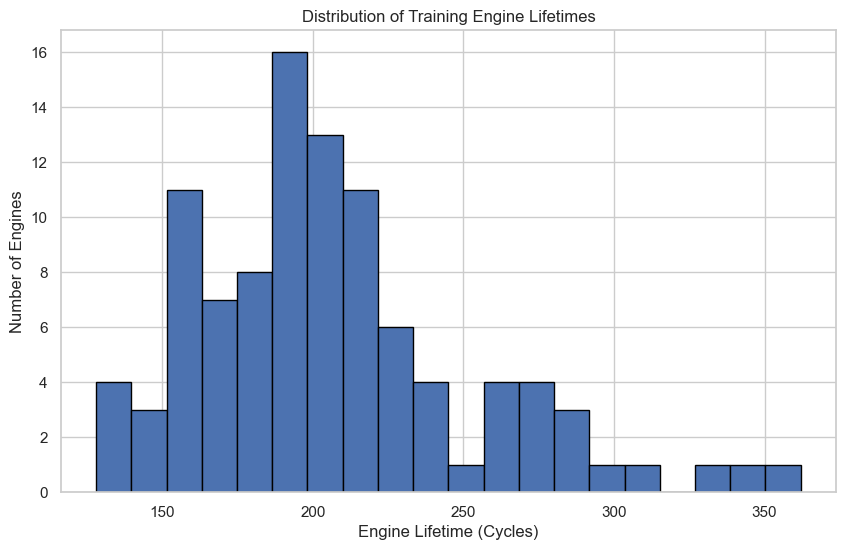

In [94]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_engine_cycles,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Engine Lifetime (Cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Training Engine Lifetimes")

plt.show()

In [95]:
def create_rul(df):
    df = df.copy()

    max_cycle = df.groupby("engine_id")["cycle"].max()

    df["RUL"] = (
        df["engine_id"].map(max_cycle)
        - df["cycle"]
    )

    return df


train_rul_df = create_rul(train_df)

In [96]:
train_rul_df["RUL"].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

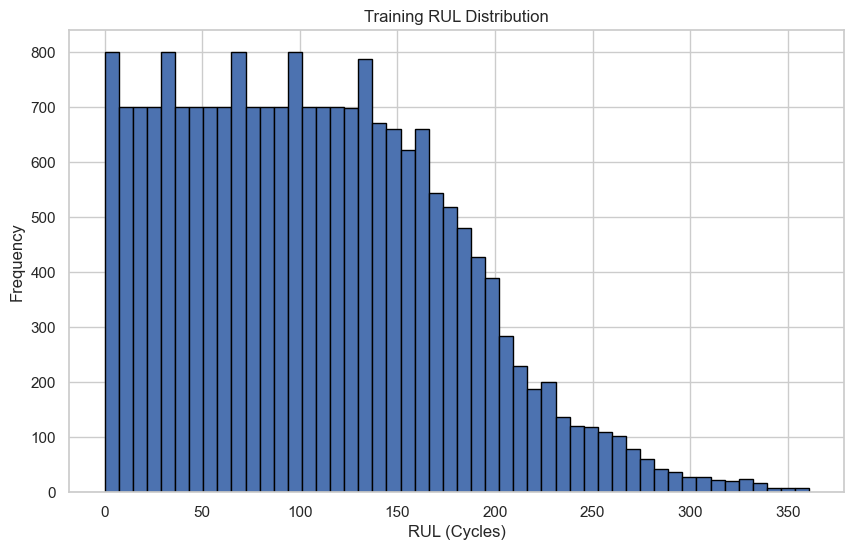

In [97]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_rul_df["RUL"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("RUL (Cycles)")
plt.ylabel("Frequency")
plt.title("Training RUL Distribution")

plt.show()

In [98]:
sensor_variance = (
    train_df[sensor_columns]
    .var()
    .sort_values()
)

sensor_variance

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    1.926023e-34
sensor_5     3.155597e-30
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64

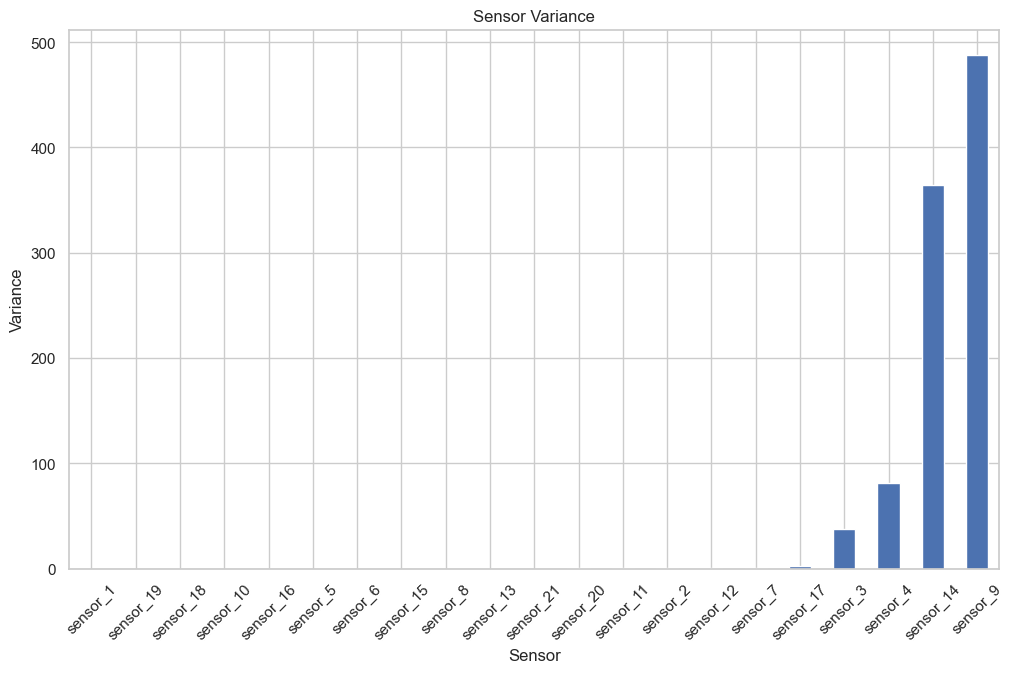

In [99]:
plt.figure(figsize=(12, 7))

sensor_variance.plot(kind="bar")

plt.xlabel("Sensor")
plt.ylabel("Variance")
plt.title("Sensor Variance")
plt.xticks(rotation=45)

plt.show()

In [100]:
constant_sensors = [
    sensor
    for sensor in sensor_columns
    if train_df[sensor].nunique() <= 1
]

constant_sensors

['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

In [101]:
train_df[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


In [102]:
rul_correlation = (
    train_rul_df[sensor_columns + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

rul_correlation

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

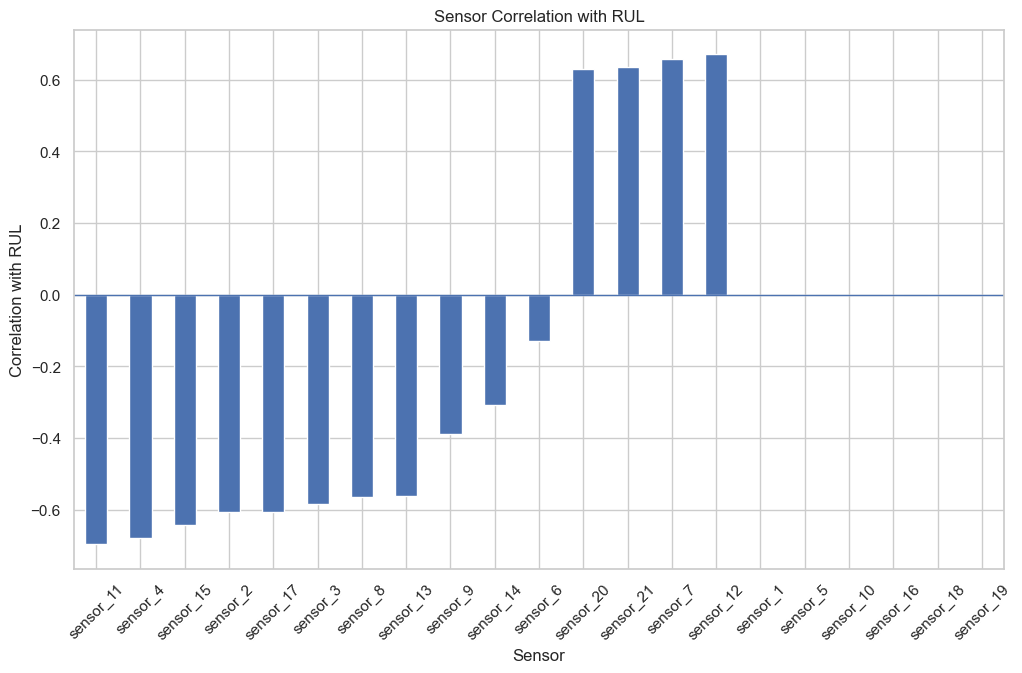

In [103]:
plt.figure(figsize=(12, 7))

rul_correlation.plot(kind="bar")

plt.axhline(0, linewidth=1)
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.title("Sensor Correlation with RUL")
plt.xticks(rotation=45)

plt.show()

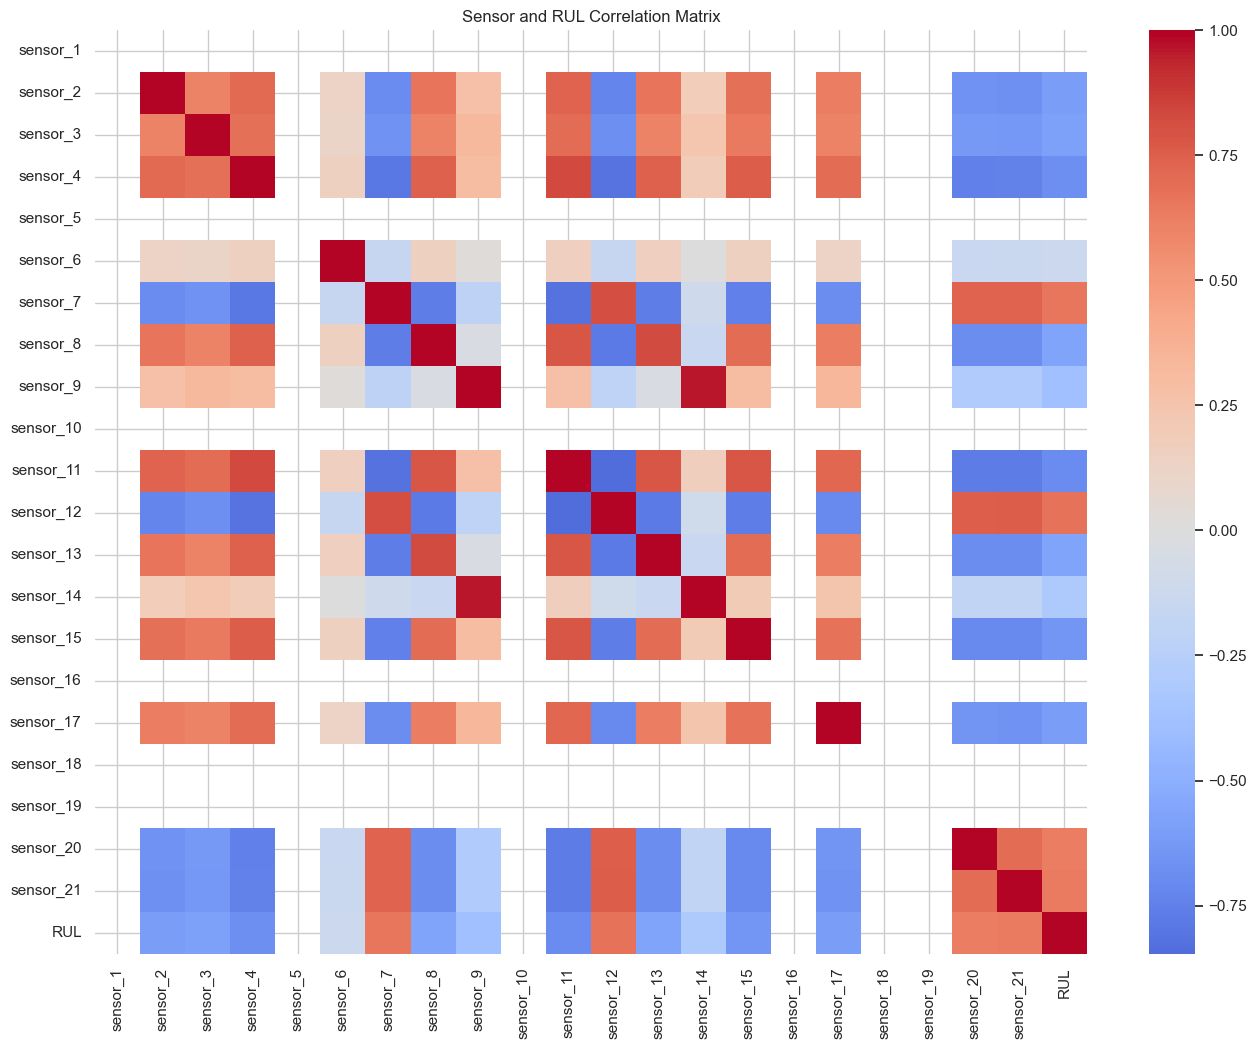

In [104]:
correlation_matrix = train_rul_df[
    sensor_columns + ["RUL"]
].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Sensor and RUL Correlation Matrix")

plt.show()

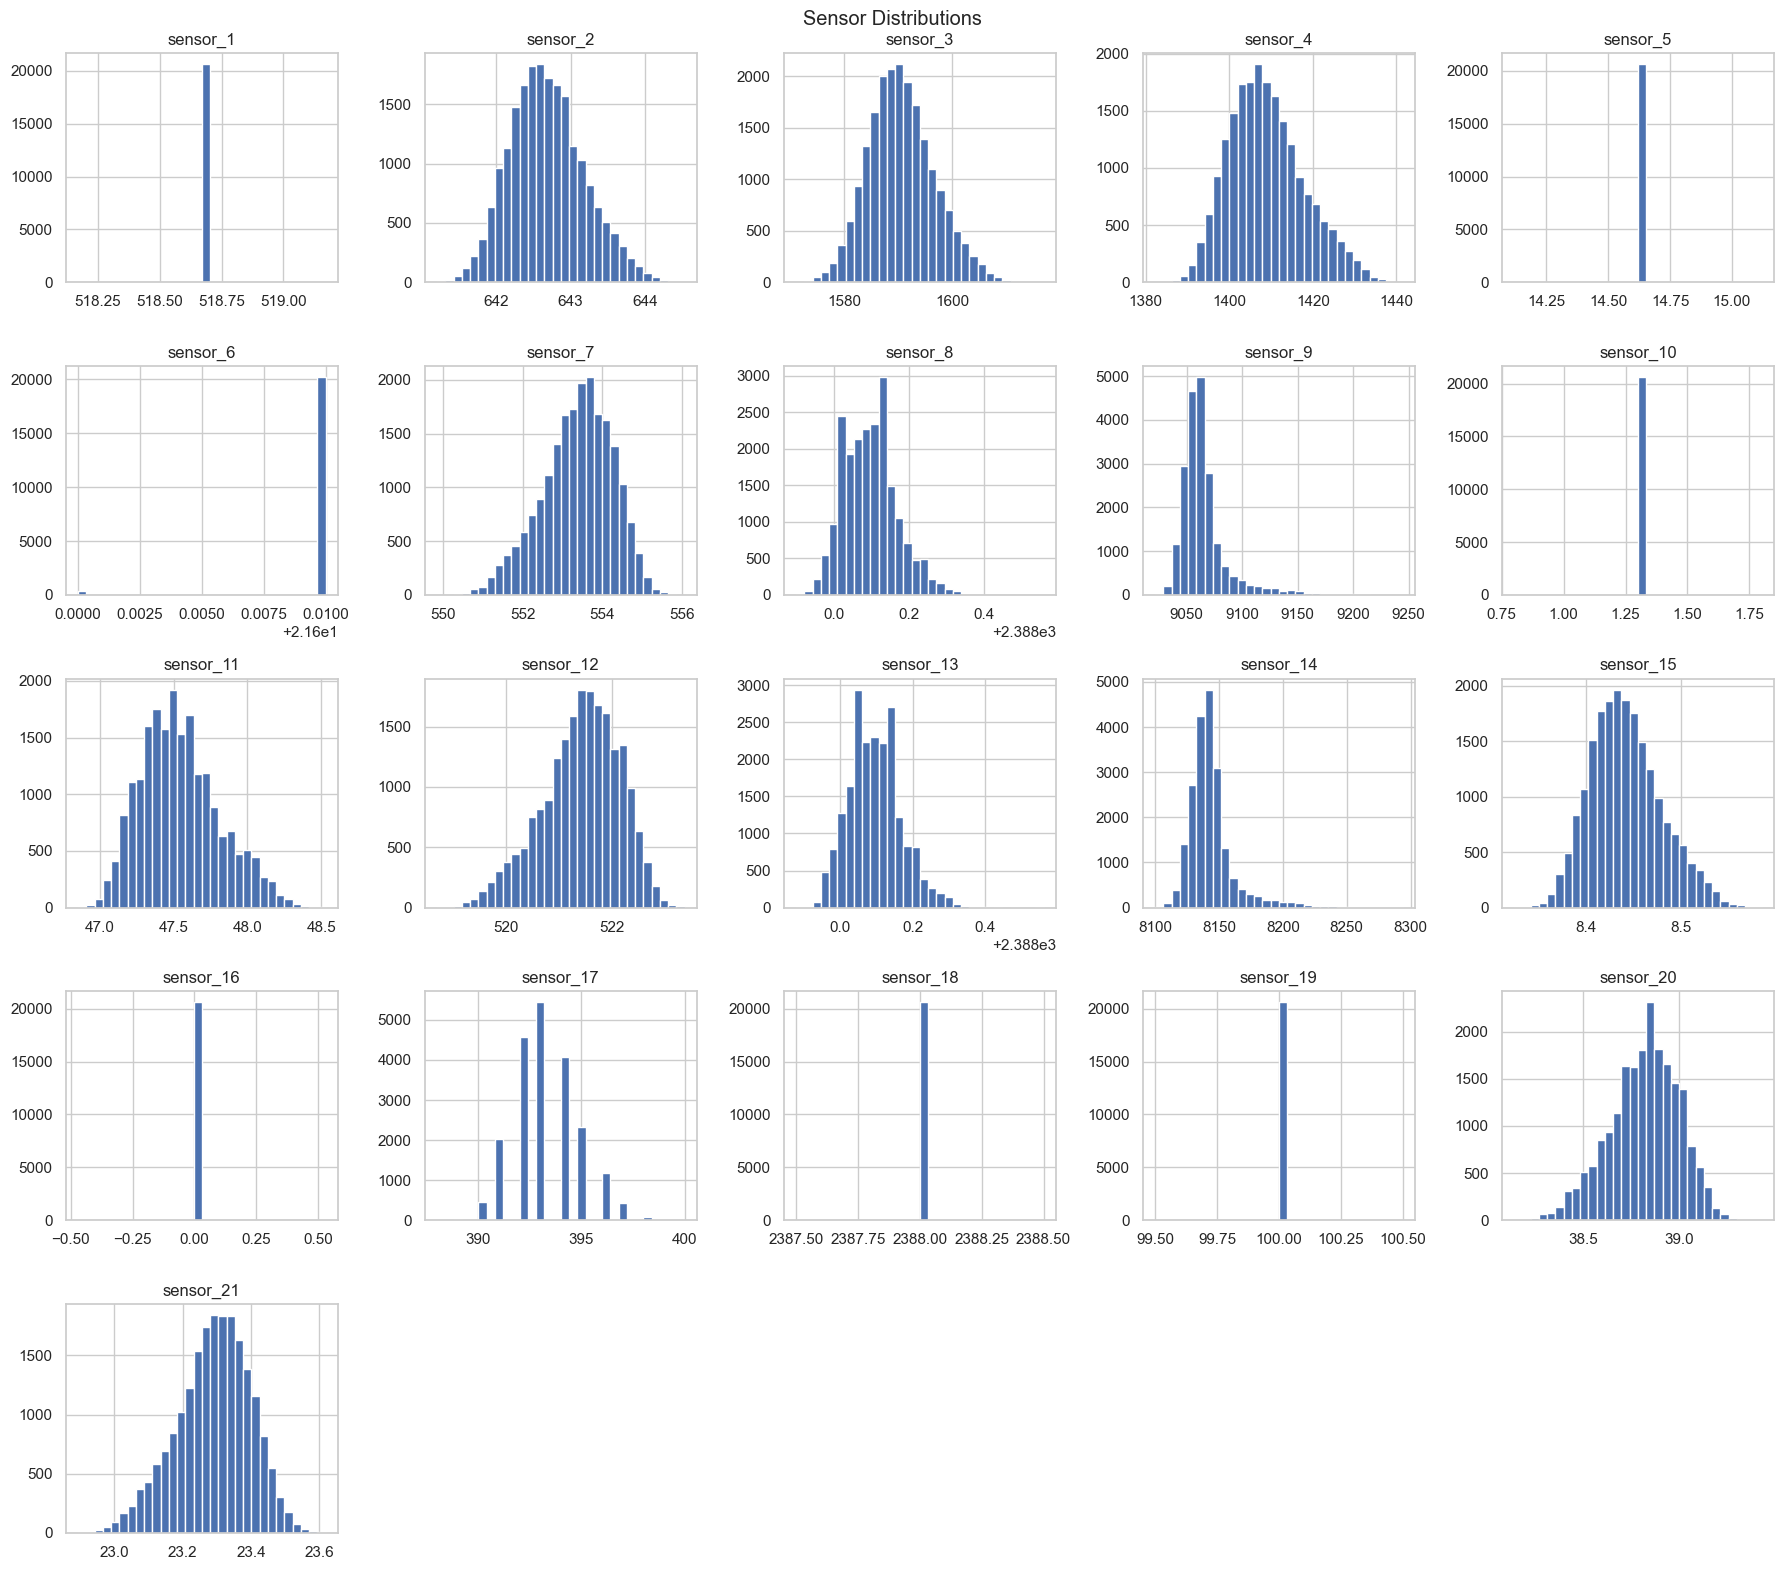

In [105]:
train_df[sensor_columns].hist(
    figsize=(18, 16),
    bins=30
)

plt.suptitle("Sensor Distributions")
plt.tight_layout()

plt.show()

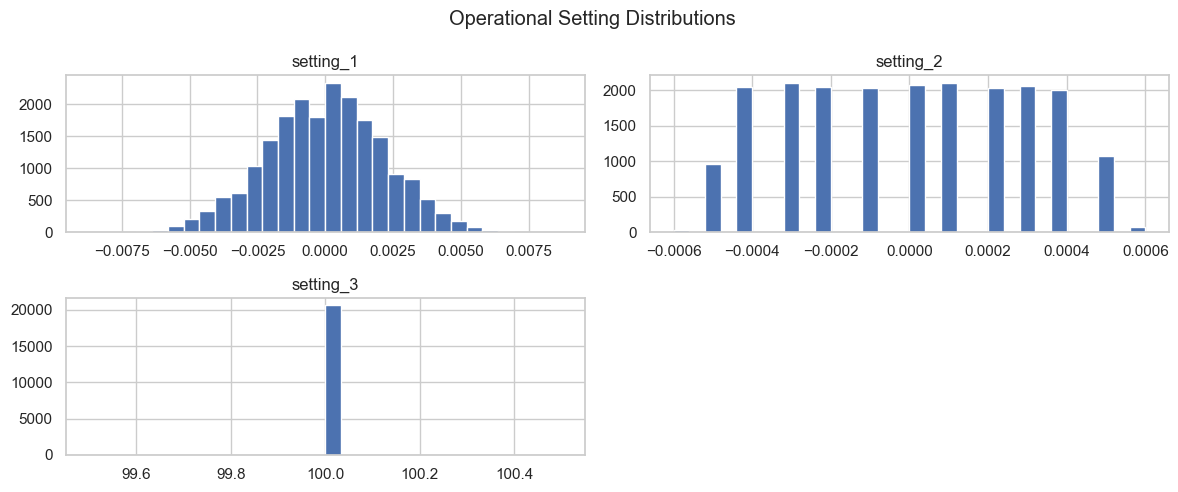

In [106]:
train_df[setting_columns].hist(
    figsize=(12, 5),
    bins=30
)

plt.suptitle("Operational Setting Distributions")
plt.tight_layout()

plt.show()

In [107]:
engine_id = 1

engine_data = train_rul_df[
    train_rul_df["engine_id"] == engine_id
]

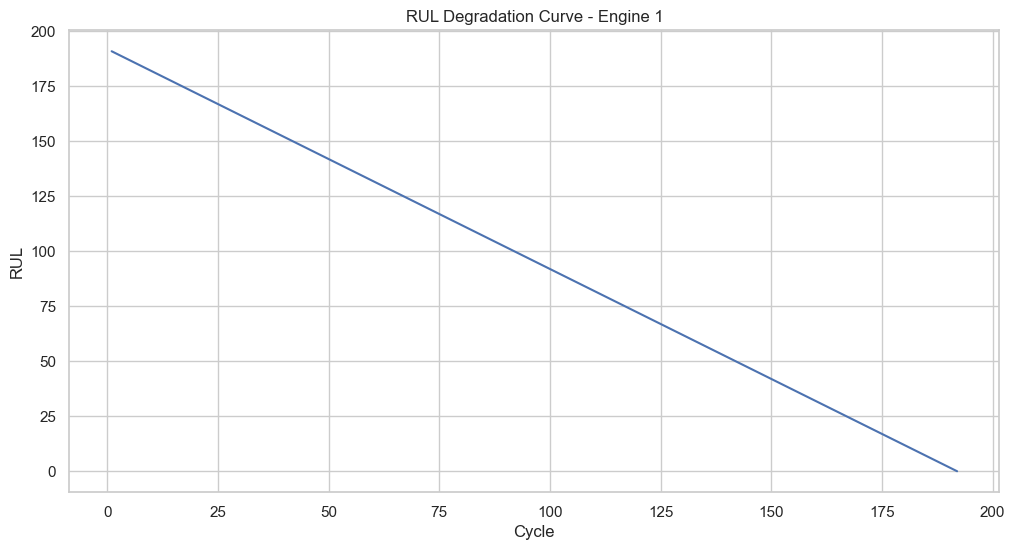

In [108]:
plt.figure(figsize=(12, 6))

plt.plot(
    engine_data["cycle"],
    engine_data["RUL"]
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL Degradation Curve - Engine 1")

plt.show()

In [110]:
sensor_mean_comparison = pd.DataFrame({
    "Train": train_df[sensor_columns].mean(),
    "Test": test_df[sensor_columns].mean()
})

sensor_mean_comparison

,Train,Test
sensor_1,518.670000,518.670000
sensor_2,642.680934,642.475088
sensor_3,1590.523119,1588.099204
sensor_4,1408.933782,1404.735362
sensor_5,14.620000,14.620000
sensor_6,21.609803,21.609701
sensor_7,553.367711,553.757523
sensor_8,2388.096652,2388.070964
sensor_9,9065.242941,9058.407363
sensor_10,1.300000,1.300000


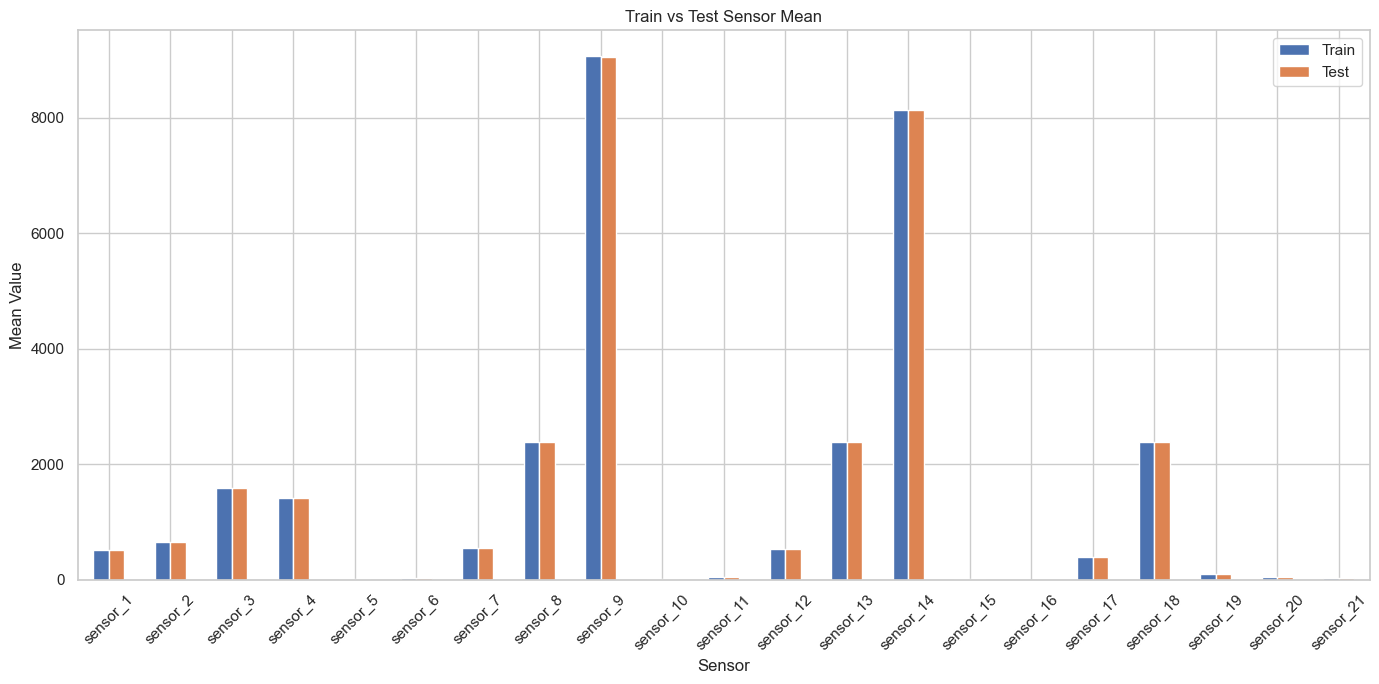

In [111]:
sensor_mean_comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.xlabel("Sensor")
plt.ylabel("Mean Value")
plt.title("Train vs Test Sensor Mean")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

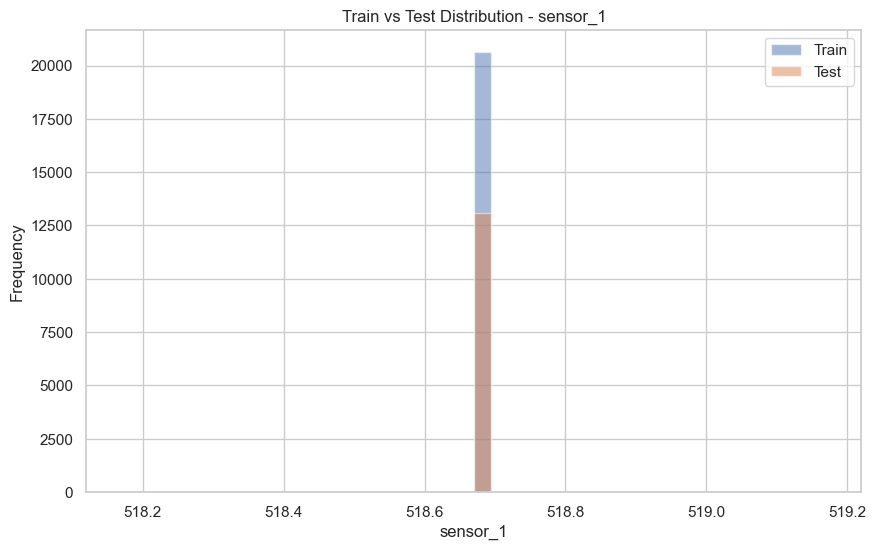

In [112]:
selected_sensor = sensor_columns[0]

plt.figure(figsize=(10, 6))

plt.hist(
    train_df[selected_sensor],
    bins=40,
    alpha=0.5,
    label="Train"
)

plt.hist(
    test_df[selected_sensor],
    bins=40,
    alpha=0.5,
    label="Test"
)

plt.xlabel(selected_sensor)
plt.ylabel("Frequency")
plt.title(f"Train vs Test Distribution - {selected_sensor}")
plt.legend()

plt.show()